_You can write your names and project group here_


# Image reconstruction using probabilistic Principal Component Analysis

## Foreword

####  Principal Component Analysis
Principal Component Analysis (PCA) is the oldest and most common technique for _dimensionality reduction_: we want to represent points $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n$ from a multidimensional space $\mathbb{R}^D$ and _embed_ them into a smaller subspace $\mathbb{R}^M$. The strategy in the case of PCA is to sequentially maximize the variance explained by each subspace $\mathbf{u}_1, \mathbf{u}_2, \ldots, \mathbf{u}_M \in \mathbb{R}^D$. We can represent the approximation of the $\mathbf{x}_i$ by its coordinates in the new system: 
$$
\mathbf{z} = (z_1, \ldots, z_M)^{T} = (\mathbf{u}_1^T \mathbf{x}, \ldots, \mathbf{u}_M^T \mathbf{x})
$$

#### Probabilistic formulation of PCA

An equivalent probabilistic formulation of PCA is to consider a hierarchical model with a latent variable $\mathbf{z} \in \mathbb{R}^M$ drawn from a isotropic gaussian, and then a projection using the matrix $W$ ($I_{D}$ is the identity matrix in $\mathbb{R}^{D\times D}$):
\begin{align*}
\mathbf{z} & \sim \mathcal{N}(0, I_{M}) \\
\mathbf{x} & = W \mathbf{z} + \mu + \varepsilon \\
\varepsilon & \sim \mathcal{N}(0, \sigma^2 I_{D} )
\end{align*}

#### Generalisation of PCA: Latent Factor Analysis
If we take out the hypothesis that the noise is isotropic, we have a model called *Latent Factor Analysis* or *Factor Analysis* (FA), where this time $\varepsilon$ has a diagonal covariance $\Psi$ ($\varepsilon \sim \mathcal{N}(0,\Psi)$). We will use this model in the following or more precisely an extension of it to mixture (mixture of factor analysers).


## Outline of the Project

In this project we will revisit the MNIST dataset using first PCA. We will then move to the probabilistic formulation and consider mixtures of pPCA/FA and see how they allow to embed the image space in a series of components with different dimensions.
We can note that this unsupervised learning approach is complementary another unsupervised learning approach we saw previously. Indeed, in project 3, we applied clustering on the same dataset. We will see how dimensionality reduction provides another way to perform image imputation. 

The project is divided into 4 parts:

1. Data loading and preprocessing.
2. Applying Principal component analysis to the data and evaluation of the approximation.
3. Applying mixtures of probabilistic PCA and Factor Analysis and evaluation of the results for data representation.
4. Using mixture of pPCA/Factor Analysers for image imputation, and compare it with the clustering results (optional)

## 1. Data loading and preprocessing


For this project, it is necessary to install the following packages for data download and for estimating Mixture of Factor analyzers:
- PyTorch 
- PyTorch lightning 

We will also make use of a published module that performed pPCA and LFA for a [paper comparing Generative Adversarial Networks with Gaussian Mixture Models](https://arxiv.org/abs/1805.12462). The original implementation in [tensorflow is here](https://github.com/eitanrich/gans-n-gmms) and the more recent pytorch version can be found [here](https://github.com/eitanrich/torch-mfa). No need to download those modules for the project, as all the necessary functions have been provided in the `mfa_helpers.py` accompanying file.




In [1]:
from data import CelebADataset

from pathlib import Path

from PIL import Image
from matplotlib import pyplot as plt

from torchvision.datasets import MNIST

from mfa_helpers import *

import torchvision.transforms as transforms


torch.manual_seed(666)


### Load and represent the data

We will start by loading the data and normalizing it with the corresponding torch data loader. We will use the torch function to load the data and transform it into flat vectors from the beginning on. Note that in this case we apply Torch functions for reshaping the tensors.


### Preparing dataset

In [2]:

## The transform options reads the data and renormalizes it
## to a one dimensional vector. 

## it is also possible to download the MNIST.zip archive and uncompress it in a data subfolder

train_dataset = MNIST(
    root='./data',
    train=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        ReshapeTransform([-1])
    ]),
    download=True
)
test_dataset = MNIST(
    root='./data',
    train=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        ReshapeTransform([-1])
    ]),
    download=True
)





### Plotting functions

We provide below some new plotting functions. Those function are provided as they can be adapted to color images, but you can also use the function from project 3 if you prefer. 


In [3]:

def samples_to_np_images(samples, image_shape=[64, 64, 3], clamp=True):
    assert len(samples.shape) == 2
    assert samples.shape[1] == np.prod(image_shape)
    assert len(image_shape) == 2 or (len(image_shape) == 3 and image_shape[2] > 1)
    samples_out = samples if not clamp else torch.clamp(samples, 0., 1.)
    if len(image_shape) == 3:
        return samples_out.reshape(-1, image_shape[2], image_shape[0], image_shape[1]).permute(0, 2, 3, 1).cpu().numpy()
    else:
        return samples_out.reshape(-1, image_shape[0], image_shape[1]).cpu().numpy()


def sample_to_np_image(sample, image_shape=[64, 64, 3]):
    return samples_to_np_images(sample.unsqueeze(0), image_shape).squeeze()


def samples_to_mosaic_any_size(grid_size, samples, image_shape=(64, 64, 3)):
    images = samples_to_np_images(samples, image_shape)
    num_cols = grid_size[1]
    num_rows = grid_size[0]
    rows = []
    for i in range(num_rows):
        rows.append(np.hstack([images[j] for j in range(i * num_cols, (i + 1) * num_cols)]))
    return (np.vstack(rows) * 255).astype(np.uint8)


In [4]:
np.prod([64, 64, 3])

np.int64(12288)



**Question 1.1**: Plot a 10 samples from the MNIST dataset, as a matrix with two rows and five columns. 

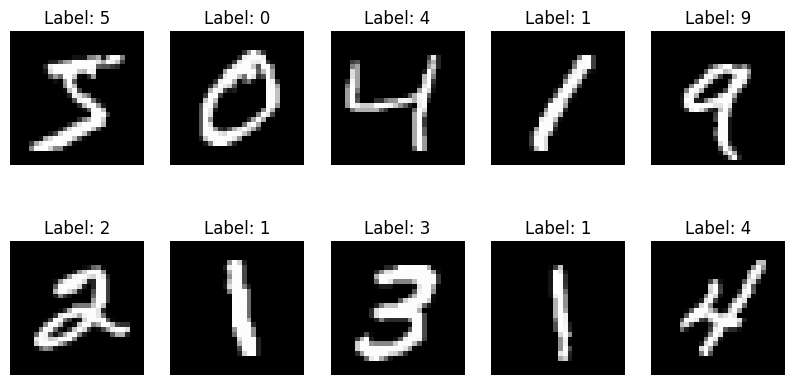

In [5]:
## You code here
train_dataset.data[:10]
fig, ax = plt.subplots(ncols=5, nrows=2, figsize=(10, 5))
for i in range(10):
    ax[i // 5, i % 5].imshow(train_dataset.data[i], cmap='gray')
    ax[i // 5, i % 5].set_title(f"Label: {train_dataset.targets[i]}")
    ax[i // 5, i % 5].axis('off')
plt.show()

**Question 1.2**: explicit how the images are expanded as vector by the pytorch functions:
 - What are the dimension of an image in the MNIST dataset? 
    - 28 x 28
 - How are the matrix coordinates $(x,y)$ of a pixel converted into an index $z$ when they are transformed into a flat vector?
    - 28*x + y (TODO: check) 

## 2. Applying PCA to the MNIST dataset

In this part we will first analyse the MNIST dataset and try to reduce the number of dimensions using PCA. First we will try to understand what are the groups of pixels that contribute to the most variability in one digits, and see how this information can be used for compression of the images. We will also apply PCA to the whole set and set what it implies for continuous representations.

- To apply PCA, you can for instance use the `sklearn` module that was proposed in the last project, after converting the data vectors. 

- By default, you can consider the train cut of the dataset, even though in this part of the project, the train/test separation is not important. 



**Question 2.1**: Choose one of the digit in the MNIST dataset and fit a Principal Component Analysis on the samples for that digit (`3` is the digit used in the Bishop): 
- Represent the mean and the first 3 principal components' basis vectors for that image. As the PC can contain negative values, renormalize the values between 0 and 1 before plotting (0 values will be plotted as grey pixels). 
- Represent the proportion of the variance captured by the principal components as a function of the number of components (you can go up to 200 components).
- How many components are needed to be able to capture more that 80%, 90% or 95% of the variance? 

  


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


indices_3 = train_dataset.data[train_dataset.targets == 3]
flattened_data = indices_3.reshape(-1, 28 * 28)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(flattened_data)
pca = PCA()  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)
X_recon = pca.inverse_transform(X_pca)
X_recon_scaled = (X_recon - X_recon.min()) / (X_recon.max() - X_recon.min())


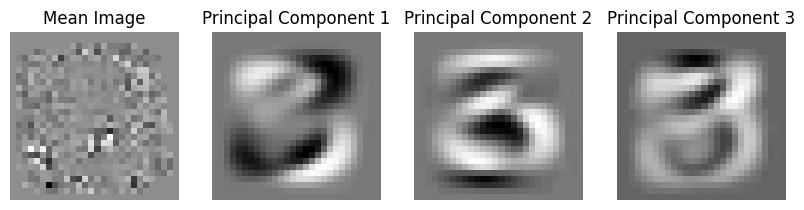

In [7]:
## You code here

#2.1.1
mu_img = pca.mean_.reshape(28, 28)
basis_img = pca.components_[:3].reshape(3, 28, 28)

mu_img = (mu_img - mu_img.min()) / (mu_img.max() - mu_img.min())
basis_img = (basis_img - basis_img.min()) / (basis_img.max() - basis_img.min())

fig, ax = plt.subplots(ncols=4, nrows=1, figsize=(10, 5))
ax[0].imshow(mu_img, cmap='gray')
ax[0].set_title("Mean Image")
ax[0].axis('off')
for i in range(3):
    ax[i + 1].imshow(basis_img[i], cmap='gray')
    ax[i + 1].set_title(f"Principal Component {i + 1}")
    ax[i + 1].axis('off')
plt.show()

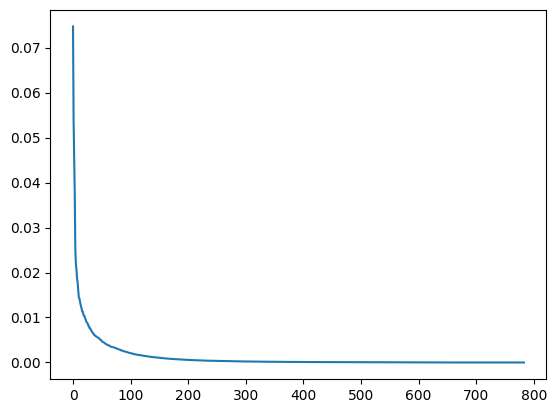

In [8]:
#2.1.2
plt.plot(pca.explained_variance_ratio_)

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#2.1.3

for p in [0.8, 0.9, 0.95]:
    pca = PCA(n_components=p)
    X_pca = pca.fit_transform(X_scaled)
    print(f"Variance retained with {p*100}% components: {pca.n_components_}")


Variance retained with 80.0% components: 90
Variance retained with 90.0% components: 151
Variance retained with 95.0% components: 224


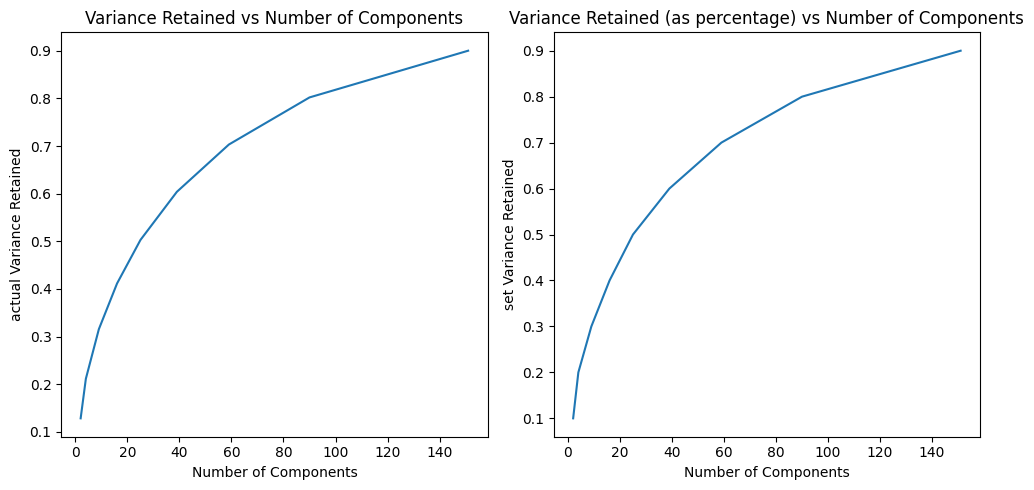

In [10]:
num_components = []
percentages = []
param = []
for i in range(1, 10):
    p = i/10.0
    pca = PCA(n_components=p)
    X_pca = pca.fit_transform(X_scaled)
    num_components.append(pca.n_components_)
    percentages.append(pca.explained_variance_ratio_.sum())
    param.append(p)
    
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))
ax[0].plot( num_components, percentages)
ax[0].set_ylabel("actual Variance Retained")
ax[0].set_xlabel("Number of Components")
ax[0].set_title("Variance Retained vs Number of Components")
ax[1].plot(num_components, param )
ax[1].set_ylabel("set Variance Retained")
ax[1].set_xlabel("Number of Components")
ax[1].set_title("Variance Retained (as percentage) vs Number of Components")
plt.tight_layout()
plt.show()



**Question 2.2**: For the digit that was chosen, we will now take one sample and reconstruct it using $M=1, 10, 50$, and $250$ principal components. Let's have a look at the results:
- Plot the original and the reconstructed images, as show below for the digit `3` (taken from the chapter 12 of the Bishop book).
- What is the compression ratio achieved for each value of $M$?
- What is the Mean-Squared Error achieved (over all pixel) for each values of $M$? 



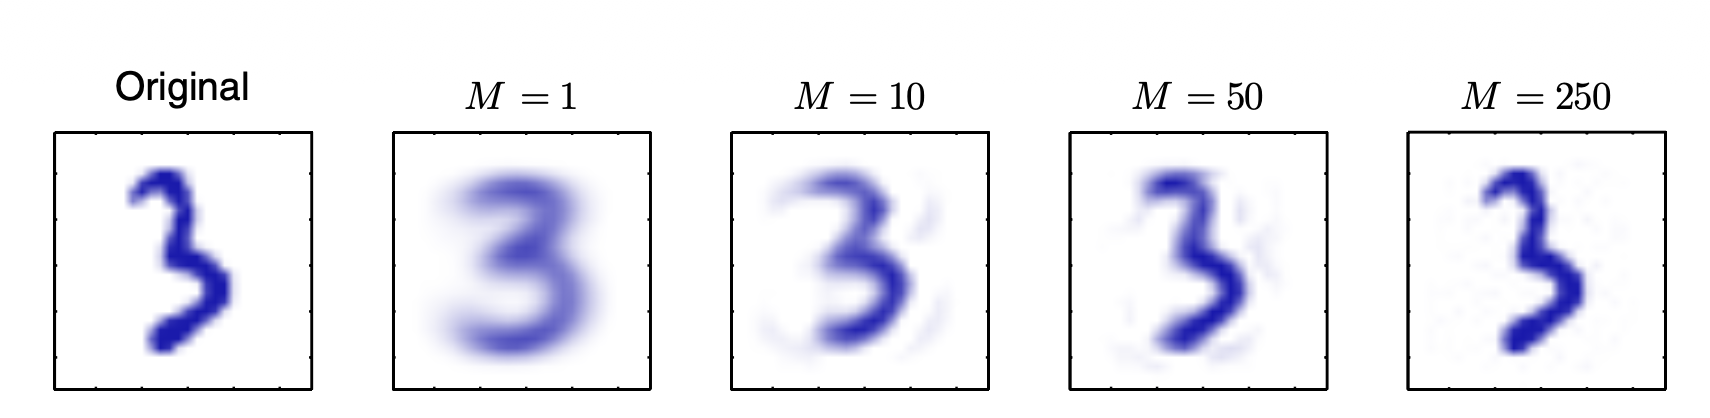

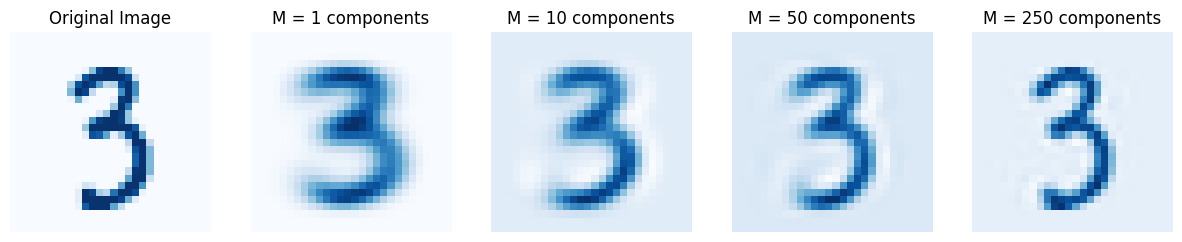

In [11]:
## Your code here 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


index = 10

img_data = [indices_3[index].reshape(28, 28)]

for i in [1, 10, 50, 250]:
    pca = PCA(n_components=i)
    X_pca = pca.fit_transform(X_scaled)
    X_recon = scaler.inverse_transform(pca.inverse_transform(X_pca))[index]
    img_data.append(X_recon.reshape(28, 28))
fig, ax = plt.subplots(ncols=5, nrows=1, figsize=(15, 5))
ax[0].imshow(img_data[0], cmap='Blues')
ax[0].set_title("Original Image")
ax[0].axis('off')
for i in range(4):
    ax[i + 1].imshow(img_data[i + 1], cmap='Blues')
    ax[i + 1].set_title(f"M = { [1, 10, 50, 250][i] } components")
    ax[i + 1].axis('off')
plt.show()  


In [12]:
for M in [1, 10, 50, 250]:
    print(f"compression for M={M}: {784.0/M}")

compression for M=1: 784.0
compression for M=10: 78.4
compression for M=50: 15.68
compression for M=250: 3.136


In [13]:
# What is the Mean-Squared Error achieved (over all pixel) for each values of $M$? 
mse_values = []
index = 10
for M in [1, 10, 50, 250]:
    pca = PCA(n_components=M)
    X_pca = pca.fit_transform(X_scaled)
    X_recon = scaler.inverse_transform(pca.inverse_transform(X_pca))
    mse = np.mean((X_recon[index] - scaler.inverse_transform(X_scaled)[index])**2)
    mse_values.append(mse)
    print(f"MSE for M={M}: {mse}")

#TODO check why x_recon ranges from -30 to +288

MSE for M=1: 1940.7561374062152
MSE for M=10: 1081.9368038497596
MSE for M=50: 484.07300915173613
MSE for M=250: 101.82841881620953



**Question 2.3**: We will now apply PCA to the MNIST dataset with *all digits*. The idea is to see how the different digits are represented on the first principal components and how the dimensionality reduction still allows compression:
- Represent the samples on the first two principal components with a pairplot. You can take for instance `0`, `1`, and `2` and plot them in 3 different colors.
     1.  How are the digits occupying the plane? Do you notice some grouping?
     2.  Consider one digit and spread on the plane, how do they change as you move along?
- Represent the mean and the first 3 Principal Components, as in question 2.1.
- Redo the compression experiment for the sample you considered in Q2.2, how are the reconstruction and the MSE now?



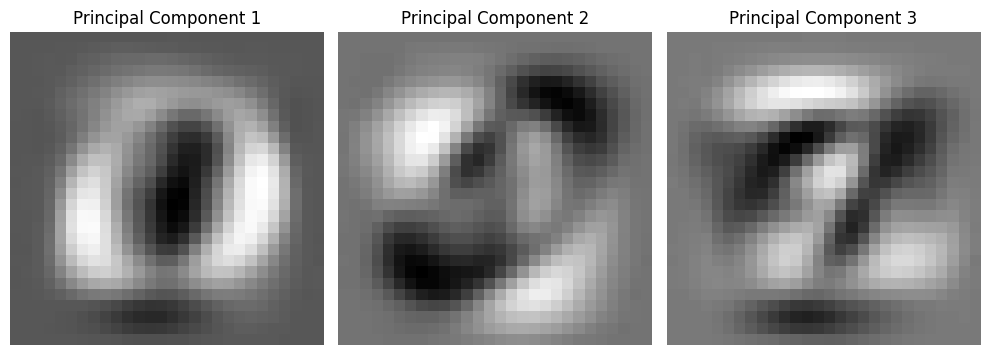

In [14]:
## Your code here

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


flattened_data = train_dataset.data.reshape(-1, 28 * 28)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(flattened_data)
pca = PCA(n_components=0.9)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(10, 5))

for i in range(3):
    img = pca.components_[i]
    img_reshaped = img.reshape(28, 28)
    ax[i].imshow(img_reshaped, cmap='gray')
    ax[i].set_title(f"Principal Component {i+1}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()


In [15]:
# its obvious that the correct parameter is 5️⃣
import pandas as pd
import seaborn as sns


pca = PCA(n_components=0.8)
results = pca.fit(X_scaled)

pca_column_names = [f"component_{i}" for i in range(1, pca.n_components_ + 1)]
transformed_pcas = pd.DataFrame(columns=pca_column_names)
transformed_pcas[pca_column_names] = pca.transform(X_scaled)
transformed_pcas_w_annotation = pd.concat(
    [transformed_pcas, pd.Series(train_dataset.targets.numpy(), name="number")],
    axis=1
)

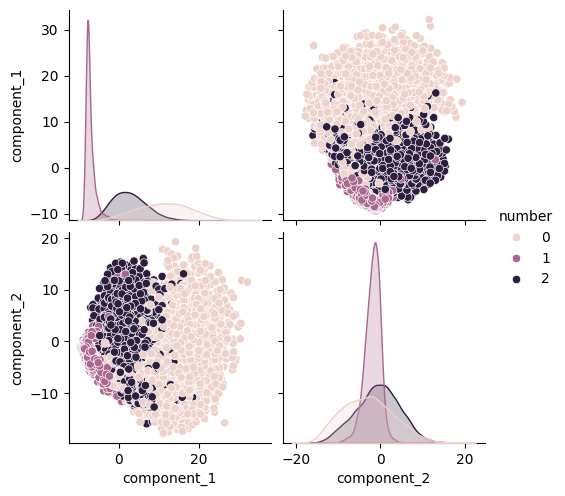

In [16]:
subset = transformed_pcas_w_annotation[
    transformed_pcas_w_annotation["number"].isin([0, 1, 2])
]

sns.pairplot(
    data=subset,
    vars=pca_column_names[:2],
    hue="number"
)

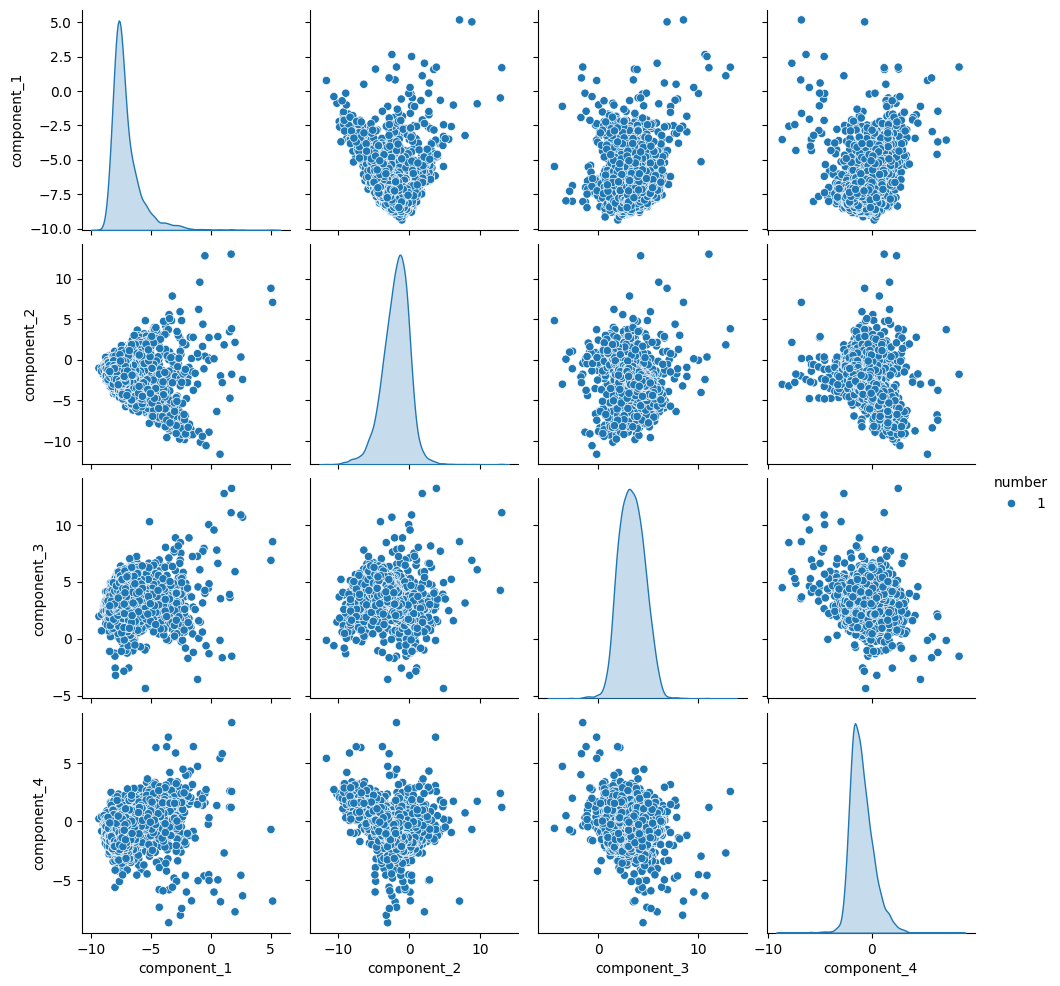

In [17]:
subset = transformed_pcas_w_annotation[
    transformed_pcas_w_annotation["number"].isin([ 1])
]

sns.pairplot(
    data=subset,
    vars=pca_column_names[:4],
    hue="number"
)

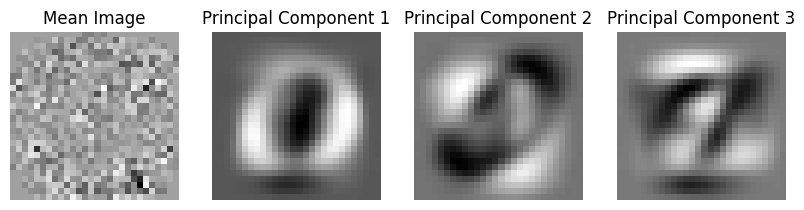

In [18]:
#Represent the mean and the first 3 Principal Components, as in question 2.1.

## You code here

mu_img = pca.mean_.reshape(28, 28)
basis_img = pca.components_[:3].reshape(3, 28, 28)

mu_img = (mu_img - mu_img.min()) / (mu_img.max() - mu_img.min())
basis_img = (basis_img - basis_img.min()) / (basis_img.max() - basis_img.min())

fig, ax = plt.subplots(ncols=4, nrows=1, figsize=(10, 5))
ax[0].imshow(mu_img, cmap='gray')
ax[0].set_title("Mean Image")
ax[0].axis('off')
for i in range(3):
    ax[i + 1].imshow(basis_img[i], cmap='gray')
    ax[i + 1].set_title(f"Principal Component {i + 1}")
    ax[i + 1].axis('off')
plt.show()

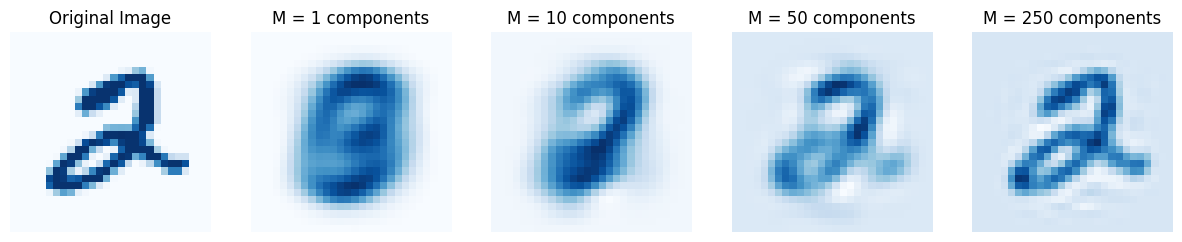

In [19]:
#- Redo the compression experiment for the sample you considered in Q2.2, how are the reconstruction and the MSE now?
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

index = 5

img_data = [flattened_data[index].reshape(28, 28)]

for i in [1, 10, 50, 250]:
    pca = PCA(n_components=i)
    X_pca = pca.fit_transform(X_scaled)
    X_recon = scaler.inverse_transform(pca.inverse_transform(X_pca))[index]
    img_data.append(X_recon.reshape(28, 28))
fig, ax = plt.subplots(ncols=5, nrows=1, figsize=(15, 5))
ax[0].imshow(img_data[0], cmap='Blues')
ax[0].set_title("Original Image")
ax[0].axis('off')
for i in range(4):
    ax[i + 1].imshow(img_data[i + 1], cmap='Blues')
    ax[i + 1].set_title(f"M = { [1, 10, 50, 250][i] } components")
    ax[i + 1].axis('off')
plt.show()  


## 3. Using MFA/MPPCA on the MNIST dataset

In this part we will train different mixture of factor analysis (MFA) models on the MNIST dataset and see how it performs. 
A mixture of factor analyser correspond to $K$ latent variables $\mathbf{z}_1, \ldots, \mathbf{z}_K$ which have each a number of factors $M$ (dimensionality reduction). 

We can write it as an extension of the previous pPCA and FA to mixtures:
$$
\mathbf{x} = \sum_{k=1}^{K} \pi_k\cdot W_k \mathbf{z}_k + \mu_k + \varepsilon_k
$$
Like for pPCA, $\mathbf{z_k} \sim \mathcal{N}(0, I_{M})$, and 
$\varepsilon_k \sim \mathcal{N}(0, \Psi_k)$


### Model training

The training of the model can be done by specifying its parameters with the `MFA` class, and then using the `batch_fit` torch primitive. 

The class `MFA` contains the following set of parameters (more details in `mfa.py`):
  - `n_features`: the number of features $D$
  - `n_components`: the parameter $K$
  - `n_factors`: the parameter $M$
  - `common_subspace`: a tensor of all the matrices $W_k$ of shape `[K, D, M]`.
  - `log_component_variances`: a tensor of the log variances $\log \Psi_k$ of shape `[K, D]`.
  - `PI_logits`: vector of the log-mixing coefficients: $(\log \pi_k)_{k=1,\ldots, K}$.

To create a new model with no fixed parameters, you just need to specify `n_features`, `n_components`, and `n_factors`. 
You can then use the torch primitive `batch_fit`. We recommend using the following parameters for training:
- maximum of 10 EM steps
- a batch size of 128 samples.

All default parameters are provided in the example code below. The manipulation of such models is more involved, so in this part of the project you are expected to manipulate helpers functions and provide comments and interpretations at each step of the analysis.

**Question 3.1**: Let's consider the basic properties of pPCA/FA and their mixture versions:
- Verify that the number of free parameters for a probabilistic PCA is $D(M+1) +1$ and $D(M+2)$ for a single factor analyzer
- What are the number of parameters for a mixture of factor analyzers?



For PPCA there the model fits a matrix of dimensions DM, a mu vector of dimension D and a single noise parameter. Thus there are $DM + D + 1 = D(M+1) +1$ free parameters.
For FA again there is a linear transformation of dimensions $DM$ and a mu vector with $D$ dimensions. Additionally, each dimension has an error variance as opposed to a single variance paramater as in PPCA. Thus, there are $DM+ D+ D$ free parameters and  $DM+ D+ D = D(M+ 1+ 1) = D(M+ 2)$ 


MFA combines $K$ FA models. Therefore it has $KD(M+2)$ free parameters.

**Question 3.2**: Let's see how the MFA model can be trained on the MNIST dataset. We will fix $M$ the number of factors/PC to $2$, and vary $K$, the number of components.
- **a**. Train an MFA with $K=10$ components on the MNIST dataset (example code is provided below)
- **b**. For each component in the mixture, represent the mean and the first Principal Components. You can help yourself with the `visualize_model` helper function. What do you notice about the components? 
- **c**. Train other models with $K=20$ and $K=50$ components and compare the likelihoods. 
- **d**. Check how the reconstruction works for one digit with $K=10, 20, 50$ (you can use the same digit as the one you used in part 2). Report the MSE of the reconstructions as well. What the compression ratio in that case? 


In [ ]:
##
## Parameters for running the mixture of components
## 

## This bolean switch allows to load an already trained model
retrain = False
##
image_shape = [28, 28]  # The input image shape
n_components = 10  # Number of components in the mixture model
n_factors = 2  # Number of factors - the latent dimension (same for all components)
batch_size = 128  # The EM batch size
num_iterations = 10

## Template model_name to save the results in a folder
model_name = f'MNIST_{n_components}_l_{n_factors}_iter_{num_iterations}'

## preparing folder for saving the models and the figures
device = torch.device('cpu')
model_dir = Path('models/')
model_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path('./figures/') / model_name
figures_dir.mkdir(exist_ok=True, parents=True)
model_path = Path(model_dir / f'model_{model_name}.pth')

## Defining an MFA model, only needs K, D, and M.
print('Defining the MFA model...')
model = MFA(
    n_components=n_components,
    n_features=np.prod(image_shape),
    n_factors=n_factors,
).to(device=device)

## Model training, note the retrain boolean to allow reloading a model.
ll_log = []
if not retrain and model_path.exists():
    print('Loading existing model...', end='')
    load = torch.load(model_path, weights_only=True)
    model.load_state_dict(load)
    print('Done.')
else:
    print(f'EM fitting: {n_components=} / {n_factors=} / {batch_size=} ...')

    ll_log = model.batch_fit(
        train_dataset,
        test_dataset,
        batch_size=batch_size,
        max_iterations=num_iterations,
    )

    print('Saving the model...', end='')
    torch.save(model.state_dict(), model_path)
    print('Done.')

Defining the MFA model...
Loading existing model...Done.


In [21]:
# For question 3.2.b
# Visualizes the components of the trained MFA model. 
# The header shows the mean and the std. dev. of each component. 
# The rows below show the factors: mean, direction/factor loadings, and
# mean - direction/factor loadings.

print('Visualizing the trained model...')
image_mode = 'L' if len(image_shape) == 2 else 'RGB'
model_image = visualize_model(model, image_shape=image_shape, end_component=10)
img = Image.fromarray(model_image, mode=image_mode)
img.show()
img.save(figures_dir / 'model_vis.png')


Visualizing the trained model...


In [ ]:
## Your code/comments here

answer to 3.2.b:
- each mu for a class ressembles a mixture of different numbers / different writings styles for a number
- the basis factor each seem to sepperate this mu into classes of similar numbers


In [22]:
##
## Parameters for running the mixture of components
## 

## This bolean switch allows to load an already trained model
retrain = False
##
image_shape = [28, 28]  # The input image shape
n_components = 20  # Number of components in the mixture model
n_factors = 2  # Number of factors - the latent dimension (same for all components)
batch_size = 128  # The EM batch size
num_iterations = 10

## Template model_name to save the results in a folder
model_name = f'MNIST_{n_components}_l_{n_factors}_iter_{num_iterations}'

## preparing folder for saving the models and the figures
device = torch.device('cpu')
model_dir = Path('models/')
model_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path('./figures/') / model_name
figures_dir.mkdir(exist_ok=True, parents=True)
model_path = Path(model_dir / f'model_{model_name}.pth')

## Defining an MFA model, only needs K, D, and M.
print('Defining the MFA model...')
model = MFA(
    n_components=n_components,
    n_features=np.prod(image_shape),
    n_factors=n_factors,
).to(device=device)

## Model training, note the retrain boolean to allow reloading a model.
ll_log = []
if not retrain and model_path.exists():
    print('Loading existing model...', end='')
    load = torch.load(model_path, weights_only=True)
    model.load_state_dict(load)
    print('Done.')
else:
    print(f'EM fitting: {n_components=} / {n_factors=} / {batch_size=} ...')

    ll_log = model.batch_fit(
        train_dataset,
        test_dataset,
        batch_size=batch_size,
        max_iterations=num_iterations,
    )

    print('Saving the model...', end='')
    torch.save(model.state_dict(), model_path)
    print('Done.')

Defining the MFA model...
Loading existing model...Done.


In [ ]:
##
## Parameters for running the mixture of components
## 

## This bolean switch allows to load an already trained model
retrain = False
##
image_shape = [28, 28]  # The input image shape
n_components = 50  # Number of components in the mixture model
n_factors = 2  # Number of factors - the latent dimension (same for all components)
batch_size = 128  # The EM batch size
num_iterations = 10

## Template model_name to save the results in a folder
model_name = f'MNIST_{n_components}_l_{n_factors}_iter_{num_iterations}'

## preparing folder for saving the models and the figures
device = torch.device('cpu')
model_dir = Path('models/')
model_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path('./figures/') / model_name
figures_dir.mkdir(exist_ok=True, parents=True)
model_path = Path(model_dir / f'model_{model_name}.pth')

## Defining an MFA model, only needs K, D, and M.
print('Defining the MFA model...')
model_50 = MFA(
    n_components=n_components,
    n_features=np.prod(image_shape),
    n_factors=n_factors,
).to(device=device)

## Model training, note the retrain boolean to allow reloading a model.
ll_log = []
if not retrain and model_path.exists():
    print('Loading existing model...', end='')
    load = torch.load(model_path, weights_only=True)
    model_50.load_state_dict(load)
    print('Done.')
else:
    print(f'EM fitting: {n_components=} / {n_factors=} / {batch_size=} ...')

    ll_log = model_50.batch_fit(
        train_dataset,
        test_dataset,
        batch_size=batch_size,
        max_iterations=num_iterations,
    )

    print('Saving the model...', end='')
    torch.save(model_50.state_dict(), model_path)
    print('Done.')

Defining the MFA model...
Loading existing model...Done.


3.2.c:
- in both scenarios the log likelihood increases with the number of iterations, since the model is fitted more and more to the data 
- for K=50 the final likelihood is greater
- this is probably because more components allow the model to retain more of the underlaying variance and thus fit closer to the actual distribution


 **d**: Check how the reconstruction works for one digit with $K=10, 20, 50$ (you can use the same digit as the one you used in part 2). Report the MSE of the reconstructions as well. What the compression ratio in that case? 

/Users/jannisarnold/Documents/Uni/ApPML/AppliedPML_GroupA/PCA/mfa_helpers.py:309: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  *[MFA._small_sample_ppca(x[component_samples[i]], n_factors=l) for i in range(K)])]


Using test sample index: 10 label: 3

Training MFA with K=10 ...
Random init with 6 samples per component...
Iteration 0/10, log-likelihood=11.272774696350098:


E-step: processing batches: 100%|██████████| 48/48 [00:09<00:00,  4.90it/s]

M-step: updating parameters

 (9.86 sec)
Iteration 1/10, log-likelihood=194.54290771484375:


...

M-step: updating parameters

 (6.71 sec)
Iteration 9/10, log-likelihood=269.99859619140625:


E-step: processing batches: 100%|██████████| 48/48 [00:06<00:00,  7.15it/s]

M-step: updating parameters

 (6.84 sec)

Final train log-likelihood=270.1336975097656:
K=50: MAP component k*=0, z=[-1.0638287  -0.43452618], MSE=0.02858632616698742


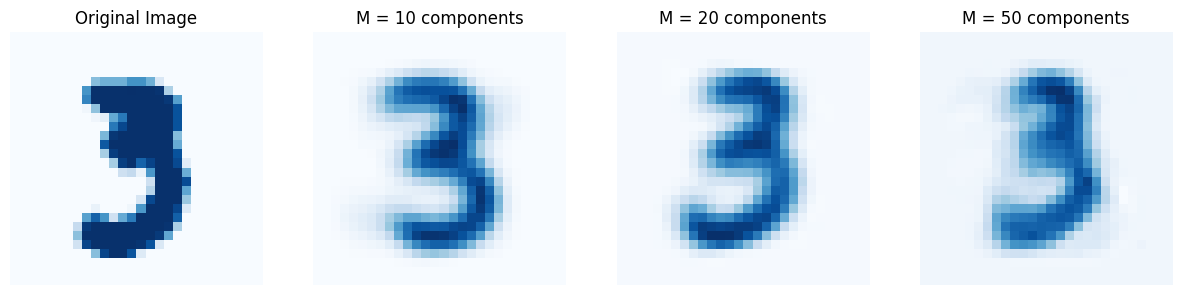

In [30]:
import numpy as np
import torch
from torch.utils.data import Subset

digit = 3  

train_subset_idx = [i for i, y in enumerate(train_dataset.targets) if int(y) == digit]
test_subset_idx  = [i for i, y in enumerate(test_dataset.targets)  if int(y) == digit]

train_dataset_subset = Subset(train_dataset, train_subset_idx)
test_dataset_subset  = Subset(test_dataset, test_subset_idx)

device = torch.device("cpu")
image_shape = [28, 28]
D = int(np.prod(image_shape))

n_factors = 2
batch_size = 128
num_iterations = 10

# Match PCA exercise: compute MSE for a single picture
index = 10
x, y = test_dataset_subset[index]
x = x.to(device).float().view(1, -1)  # [1, 784]
print("Using test sample index:", index, "label:", int(y))

def project_to_z_and_reconstruct(model: MFA, x: torch.Tensor):
    """
    1) Choose MAP component k*
    2) Project x -> z (posterior mean in latent space)
    3) Reconstruct x_hat from z via mu + A z
    Returns: z_mean [M], x_hat [1,D], k_star int
    """
    with torch.no_grad():
        # MAP component (discrete assignment)
        k_star = int(model.map_component(x).item())

        # Parameters of that component
        mu = model.means[k_star]                       # [D]
        A = model.common_subspace[k_star]              # [D, M]
        log_var = model.log_component_variances[k_star]# [D]

        # Diagonal noise covariance: Psi = diag(exp(log_var))
        # We need Psi^{-1} for the posterior
        inv_psi = torch.exp(-log_var)                  # [D]

        # Centered observation
        xc = (x.squeeze(0) - mu)                       # [D]

        # Posterior mean:
        # z = (I + A^T Psi^{-1} A)^{-1} A^T Psi^{-1} (x - mu)
        A_T_invPsi = (A.T * inv_psi)                   # [M, D]
        L = torch.eye(model.n_factors, device=x.device) + A_T_invPsi @ A  # [M, M]
        z_mean = torch.linalg.solve(L, A_T_invPsi @ xc)                   # [M]

        # Decode / reconstruct
        x_hat = mu + A @ z_mean                        # [D]
        return z_mean, x_hat.view(1, -1), k_star

mse_values = []

fig, ax = plt.subplots(ncols=4, nrows=1, figsize=(15, 5))

ax[0].imshow(x.view(28, 28).cpu().numpy(), cmap='Blues')
ax[0].set_title("Original Image")
ax[0].axis('off')
i = 0

for K in [10, 20, 50]:
    print(f"\nTraining MFA with K={K} ...")
    model = MFA(
        n_components=K,
        n_features=D,
        n_factors=n_factors,
    ).to(device=device)

    _ = model.batch_fit(
        train_dataset_subset,
        test_dataset_subset,
        batch_size=batch_size,
        max_iterations=num_iterations,
    )

    z, x_hat, k_star = project_to_z_and_reconstruct(model, x)

    # MSE over all pixels for that single picture (same style as PCA)
    
    ax[i + 1].imshow(x_hat.view(28, 28).cpu().numpy(), cmap='Blues')
    ax[i + 1].set_title(f"M = { [10, 20, 50][i] } components")
    ax[i + 1].axis('off')
      
    mse = torch.mean((x_hat - x) ** 2).item()
    mse_values.append(mse)
    torch.save(model.state_dict(), f"models/mfa_single_K{K}_M{n_factors}_iter{num_iterations}.pth")
    print(f"K={K}: MAP component k*={k_star}, z={z.cpu().numpy()}, MSE={mse}")
    i += 1
plt.show()

28x28 - The size of a single base Vector (original dimensions/components)

K+1 - The Amount of the base vectors (reduced/principal components, plus one mu vector)

M - The number of Factors

28 x 28 x (K+1) x M - The size of the model (Consisting of M factors, that each contain a Matrix and a mu vector)

(K+M) x n - The space needed to save the entries. Each entry has a number denoting the factor it belongs to an a vector denoting its position in the reduced component space of size K (this can also be interepreted as the weights for the base vectors)

In [34]:
compute_compressed_size = lambda n, K:  (28.0 * 28.0 * (K+1)) * 2.0 + ((K + 2) * n)

In [35]:
n = len(train_dataset_subset)
for K, mse in zip([10, 20, 50], mse_values):
    compressed_size = compute_compressed_size(n, K)
    compression_ratio = (28.0 * 28.0 * n) / compressed_size 
    print(f"K={K}: MSE={mse}, compressed size (in floats) = {compressed_size:.2f}, compression ratio = {compression_ratio:.2f}")

K=10: MSE=0.033660486340522766, compressed size (in floats) = 90820.00, compression ratio = 52.93
K=20: MSE=0.02975093014538288, compressed size (in floats) = 167810.00, compression ratio = 28.64
K=50: MSE=0.02858632616698742, compressed size (in floats) = 398780.00, compression ratio = 12.05


### Simulating samples 


**Question 3.3**: We want to see how it works with simulation. On the model with $K=10$ and the one with $K=50$ components, simulate a hundred samples and plot them. Compare the properties of the samples for the different number of components.

Below an example code to generate samples and plot them.

In [36]:

print('Generating random samples...')
rnd_samples, _ = model.sample(100)
mosaic = samples_to_mosaic(rnd_samples, image_shape=image_shape)
img = Image.fromarray(mosaic)
img.show()
img.save(figures_dir / 'samples.png')



Generating random samples...


In [40]:
import numpy as np
import torch

device = torch.device("cpu")
image_shape = [28, 28]
D = int(np.prod(image_shape))
n_factors = 2
num_iterations = 10

def load_mfa(K):
    model = MFA(
        n_components=K,
        n_features=D,
        n_factors=n_factors,
    ).to(device)
    path = f"models/mfa_single_K{K}_M{n_factors}_iter{num_iterations}.pth"
    state = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    return model

model_10 = load_mfa(10)
model_50 = load_mfa(50)

In [43]:
print('Generating random samples...')
rnd_samples_10, _ = model_10.sample(100)
mosaic = samples_to_mosaic(rnd_samples_10, image_shape=image_shape)
img = Image.fromarray(mosaic)
img.show()
img.save(figures_dir / 'samples_10.png')

Generating random samples...


In [44]:
print('Generating random samples...')
rnd_samples_50, _ = model_50.sample(100)
mosaic = samples_to_mosaic(rnd_samples_50, image_shape=image_shape)
img = Image.fromarray(mosaic)
img.show()
img.save(figures_dir / 'samples_50.png')

Generating random samples...


In [ ]:
## You code/comments here

- The visual differences are small
- K=50 has less blurry samples than K=10

### Visualizing the embeddings. 

**Question 3.4**: Having an embedding in the latent space enables to maps the point in the training samples to a continuous representation. The code below is a way to represent the latent space of each component on a grid. Please describe what the code below is doing and provide a short comparison between the grids for $K=10$ and $K=50$ components. 

In [45]:
## Visualizing latent space by generating samples from a grid in the latent space

## Function for generating the samples
def generate_sample_from_latents(model, latents, component=None):
    if torch.all(model.common_subspace == 0.0):
        warnings.warn("SGD MFA training requires initialization. Please call batch_fit() first.")
    # assert latents.shape[1] == model.n_factors
    n = latents.shape[0]

    if component is None:
        c_nums = np.random.choice(
            model.n_components,
            n,
            p=torch.softmax(model.PI_logits, dim=0).detach().cpu().numpy(),
        )
    else:
        c_nums = torch.full((latents.shape[0], ), component, dtype=torch.int)
        padded_latents = torch.zeros((latents.shape[0], model.n_factors), device=latents.device)
        padded_latents[:, :latents.shape[1]] = latents

    z_d = torch.zeros(n, model.n_features, device=model.common_subspace.device)

    samples = torch.stack(
        [
            model.common_subspace[c_nums[i]] @ padded_latents[i]
            + model.means[c_nums[i]]
            + z_d[i] * torch.exp(0.5 * model.log_component_variances[c_nums[i]])
            for i in range(n)
        ]
    )

    return samples, c_nums

def grid_to_image(grid_coords, samples, image_shape=(64, 64, 3)):
    images = samples_to_np_images(samples, image_shape)
    num_cols = int(np.sqrt(grid_coords.shape[0]))
    num_rows = int(np.sqrt(grid_coords.shape[0]))
    assert num_cols * num_rows == grid_coords.shape[0], "grid_coords shape is not a perfect square"
    if len(image_shape) == 2:
        new_image = torch.zeros((num_rows * image_shape[0], num_cols * image_shape[1]), dtype=torch.float32)
        for i in range(num_rows):
            for j in range(num_cols):
                new_image[
                    i * image_shape[0]:(i + 1) * image_shape[0],
                    j * image_shape[1]:(j + 1) * image_shape[1],
                ] = torch.from_numpy(images[i * num_cols + j])
    elif len(image_shape) == 3:
        new_image = torch.zeros((num_rows * image_shape[0], num_cols * image_shape[1], image_shape[2]), dtype=torch.float32)
        for i in range(num_rows):
            for j in range(num_cols):
                new_image[
                    i * image_shape[0]:(i + 1) * image_shape[0],
                    j * image_shape[1]:(j + 1) * image_shape[1],
                    :,
                ] = torch.from_numpy(images[i * num_cols + j])
    else:
        raise ValueError("image_shape must be of length 2")

    return (new_image.numpy() * 255).astype(np.uint8)

In [48]:
## Represent all the samples on a grid, plotting commands

grid_size = 20
latent_grid = torch.linspace(-3, 3, steps=grid_size)
grid_coords = torch.cartesian_prod(latent_grid, latent_grid)  # (100,

print(grid_coords.shape)
print(model_50.n_factors)


for component_idx in range(model_50.n_components):
    samples, c_nums = generate_sample_from_latents(model_50, grid_coords, component=component_idx)

    # display samples as grid
    mosaic = grid_to_image(grid_coords, samples, image_shape=image_shape)
    img = Image.fromarray(mosaic)
    img.show()
    img.save(figures_dir / f'component_{component_idx}_latent_grid.png')


torch.Size([400, 2])
2



The code samples from the vector space that is spanned by the base vectors form the pca. This space is sampled at positions forming a regular grid. The sampled values are shown in a regular grid corresponding to the grid of sampling positions.


This means, that the plot is showing us a representation of the vector space and allows us to see what different images can be saved using this reduced space.

In [50]:
import numpy as np
import torch

device = torch.device("cpu")
image_shape = [28, 28]
D = int(np.prod(image_shape))
n_factors = 2
num_iterations = 10

def load_mfa_general(K):
    model = MFA(
        n_components=K,
        n_features=D,
        n_factors=n_factors,
    ).to(device)
    # PCA/models/model_MNIST_2_l_10_iter_10.pth
    # MNIST_{n_components}_l_{n_factors}_iter_{num_iterations}
    path = f"models/model_MNIST_{K}_l_{n_factors}_iter_{num_iterations}.pth"
    state = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    return model

model_10 = load_mfa_general(10)
model_50 = load_mfa_general(50)

In [70]:
print(grid_coords.shape)
print(model_10.n_factors)


for component_idx in range(model_10.n_components):
    samples, c_nums = generate_sample_from_latents(model_10, grid_coords, component=component_idx)

    # display samples as grid
    mosaic = grid_to_image(grid_coords, samples, image_shape=image_shape)
    img = Image.fromarray(mosaic)
    img.show()
    img.save(figures_dir / f'component_{component_idx}_latent_grid.png')


torch.Size([400, 2])
2


In [55]:
print(grid_coords.shape)
print(model_50.n_factors)


for component_idx in range(min(model_50.n_components, 10)):
    samples, c_nums = generate_sample_from_latents(model_50, grid_coords, component=component_idx)

    # display samples as grid
    mosaic = grid_to_image(grid_coords, samples, image_shape=image_shape)
    img = Image.fromarray(mosaic)
    img.show()
    img.save(figures_dir / f'component_{component_idx}_latent_grid.png')


torch.Size([400, 2])
2


In [ ]:
## You code/comments here 

### Reconstructing original masked images, impainting

**Question 3.4** We are exploring how the mixture of factors can provide impainting. The code below provides a way to mask images on part of it and perform impainting. 
- Describe what the code is doing to perform impainting. What are the quantities computed? 
- Compare the quality of the impainting for $K=10$ and $K=50$ on your selection of of the masking. 


In [ ]:
## 5 masking strategies are proposed: "center", "bottom", "top", "right", "left"
mask_type = 'bottom'
grid_size = [10,10]
print('Reconstructing images from the trained model...', end='')
n = grid_size[0] * grid_size[1]
random_samples, _ = zip(
    *[test_dataset[k] for k in RandomSampler(test_dataset, replacement=True, num_samples=n)]
)  #num_samples -> grid_size = [m1, m2]
random_samples = torch.stack(random_samples)

# w = image_shape[0]
# mask = np.ones([3, w, w], dtype=np.float32)  # Hide part of each image

# torch dimensions are generally in (C, H, W) format
shape_reversed = image_shape[::-1]
if len(shape_reversed) == 2:
    shape_reversed = [1] + shape_reversed  # Add channel dimension for grayscale images
height = shape_reversed[1]
width = shape_reversed[2]
mask = np.ones(shape_reversed, dtype=np.float32)  # Hide part of each image

if mask_type == "center":
    mask[:, height // 4:-height // 4, width // 4:-width // 4] = 0  #Masking centre
    mask_suffix = 'center'
elif mask_type == "bottom":
    mask[:, height // 2:, :] = 0  #Masking bottom half
    mask_suffix = 'bottom'
elif mask_type == "right":
    mask[:, :, width // 2:] = 0  #Masking right half
    mask_suffix = 'right'
elif mask_type == "left":
    mask[:, :, : width // 2] = 0  #Masking left half
    mask_suffix = 'left'
else:
    mask[:, :height // 2, :] = 0  #Masking top half
    mask_suffix = 'top'

mask = torch.from_numpy(mask.flatten()).reshape([1, -1])
random_samples *= mask
used_features = torch.nonzero(mask.flatten()).flatten()
reconstructed_samples = model_10.conditional_reconstruct(
    random_samples.to(device),
    observed_features=used_features
).cpu()
reconstructed_samples = random_samples * mask + reconstructed_samples * (1 - mask)

mosaic_original = samples_to_mosaic_any_size(grid_size, random_samples, image_shape=image_shape)
fname = figures_dir / f'original_samples_{mask_suffix}_masked.png'
Image.fromarray(mosaic_original).save(fname)

mosaic_reconstructed = samples_to_mosaic_any_size(grid_size, reconstructed_samples, image_shape=image_shape)
fname = figures_dir / f'reconstructed_samples_{mask_suffix}_masked.png'
Image.fromarray(mosaic_reconstructed).save(fname)
print('Done.')


Reconstructing images from the trained model...Done.


In [66]:
fname

PosixPath('figures/MNIST_50_l_2_iter_10/reconstructed_samples_bottom_masked.png')

In [68]:
## 5 masking strategies are proposed: "center", "bottom", "top", "right", "left"
mask_type = 'bottom'
grid_size = [10,10]
print('Reconstructing images from the trained model...', end='')
n = grid_size[0] * grid_size[1]
random_samples, _ = zip(
    *[test_dataset[k] for k in RandomSampler(test_dataset, replacement=True, num_samples=n)]
)  #num_samples -> grid_size = [m1, m2]
random_samples = torch.stack(random_samples)

# w = image_shape[0]
# mask = np.ones([3, w, w], dtype=np.float32)  # Hide part of each image

# torch dimensions are generally in (C, H, W) format
shape_reversed = image_shape[::-1]
if len(shape_reversed) == 2:
    shape_reversed = [1] + shape_reversed  # Add channel dimension for grayscale images
height = shape_reversed[1]
width = shape_reversed[2]
mask = np.ones(shape_reversed, dtype=np.float32)  # Hide part of each image

if mask_type == "center":
    mask[:, height // 4:-height // 4, width // 4:-width // 4] = 0  #Masking centre
    mask_suffix = 'center'
elif mask_type == "bottom":
    mask[:, height // 2:, :] = 0  #Masking bottom half
    mask_suffix = 'bottom'
elif mask_type == "right":
    mask[:, :, width // 2:] = 0  #Masking right half
    mask_suffix = 'right'
elif mask_type == "left":
    mask[:, :, : width // 2] = 0  #Masking left half
    mask_suffix = 'left'
else:
    mask[:, :height // 2, :] = 0  #Masking top half
    mask_suffix = 'top'

mask = torch.from_numpy(mask.flatten()).reshape([1, -1])
random_samples *= mask
used_features = torch.nonzero(mask.flatten()).flatten()
reconstructed_samples = model_10.conditional_reconstruct(
    random_samples.to(device),
    observed_features=used_features
).cpu()
reconstructed_samples = random_samples * mask + reconstructed_samples * (1 - mask)

model_name = f'MNIST_10_l_2_iter_10'
figures_dir = Path('./figures/') / model_name

mosaic_original = samples_to_mosaic_any_size(grid_size, random_samples, image_shape=image_shape)
fname = figures_dir / f'original_samples_{mask_suffix}_masked.png'
Image.fromarray(mosaic_original).save(fname)

mosaic_reconstructed = samples_to_mosaic_any_size(grid_size, reconstructed_samples, image_shape=image_shape)
fname = figures_dir / f'reconstructed_samples_{mask_suffix}_masked.png'
Image.fromarray(mosaic_reconstructed).save(fname)
print('Done.')


Reconstructing images from the trained model...Done.


In [71]:
## 5 masking strategies are proposed: "center", "bottom", "top", "right", "left"
mask_type = 'bottom'
grid_size = [10,10]
print('Reconstructing images from the trained model...', end='')
n = grid_size[0] * grid_size[1]
random_samples, _ = zip(
    *[test_dataset[k] for k in RandomSampler(test_dataset, replacement=True, num_samples=n)]
)  #num_samples -> grid_size = [m1, m2]
random_samples = torch.stack(random_samples)

# w = image_shape[0]
# mask = np.ones([3, w, w], dtype=np.float32)  # Hide part of each image

# torch dimensions are generally in (C, H, W) format
shape_reversed = image_shape[::-1]
if len(shape_reversed) == 2:
    shape_reversed = [1] + shape_reversed  # Add channel dimension for grayscale images
height = shape_reversed[1]
width = shape_reversed[2]
mask = np.ones(shape_reversed, dtype=np.float32)  # Hide part of each image

if mask_type == "center":
    mask[:, height // 4:-height // 4, width // 4:-width // 4] = 0  #Masking centre
    mask_suffix = 'center'
elif mask_type == "bottom":
    mask[:, height // 2:, :] = 0  #Masking bottom half
    mask_suffix = 'bottom'
elif mask_type == "right":
    mask[:, :, width // 2:] = 0  #Masking right half
    mask_suffix = 'right'
elif mask_type == "left":
    mask[:, :, : width // 2] = 0  #Masking left half
    mask_suffix = 'left'
else:
    mask[:, :height // 2, :] = 0  #Masking top half
    mask_suffix = 'top'

mask = torch.from_numpy(mask.flatten()).reshape([1, -1])
random_samples *= mask
used_features = torch.nonzero(mask.flatten()).flatten()
reconstructed_samples = model_50.conditional_reconstruct(
    random_samples.to(device),
    observed_features=used_features
).cpu()
reconstructed_samples = random_samples * mask + reconstructed_samples * (1 - mask)

model_name = f'MNIST_50_l_2_iter_10'
figures_dir = Path('./figures/') / model_name

mosaic_original = samples_to_mosaic_any_size(grid_size, random_samples, image_shape=image_shape)
fname = figures_dir / f'original_samples_{mask_suffix}_masked.png'
Image.fromarray(mosaic_original).save(fname)

mosaic_reconstructed = samples_to_mosaic_any_size(grid_size, reconstructed_samples, image_shape=image_shape)
fname = figures_dir / f'reconstructed_samples_{mask_suffix}_masked.png'
Image.fromarray(mosaic_reconstructed).save(fname)
print('Done.')


Reconstructing images from the trained model...Done.
